In [1]:
# Importing libraries for data manipulation
import pandas as pd
import numpy as np

# Importing libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# This command ensures that our graphs plot directly beneath the code cells
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# URL to the raw training dataset
url = "https://raw.githubusercontent.com/Prodigy-InfoTech/data-science-datasets/main/Task%202/train.csv"

# Load the dataset into a DataFrame called 'df'
df = pd.read_csv(url)

# Display the first 5 rows to make sure it loaded correctly
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Check the dimensions of the dataset (rows, columns)
print(f"Dataset Shape: {df.shape}\n")

# Get a summary of the columns, data types, and missing values
df.info()

Dataset Shape: (891, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Count how many missing values exist in each column
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
# 1. For 'Age', we can fill missing values with the median age of the passengers
df['Age'].fillna(df['Age'].median(), inplace=True)

# 2. For 'Embarked', we fill it with the mode (the most frequent starting port)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# 3. 'Cabin' has too many missing values to fix accurately, so it's safer to drop it
df.drop(columns=['Cabin'], inplace=True)

# Verify that there are no more missing values left (except PassengerId/Name which are fine)
print("Remaining missing values:")
print(df.isnull().sum())

Remaining missing values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


C:\Users\Vinit\AppData\Local\Temp\ipykernel_21872\3463311684.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\Vinit\AppData\Local\Temp\ipykernel_21872\3463311684.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

C:\Users\Vinit\AppData\Local\Temp\ipykernel_21872\862089333.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set2')


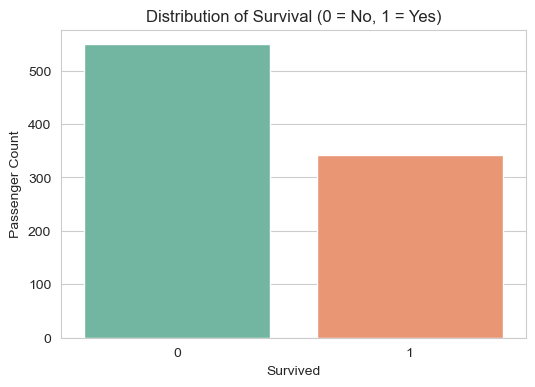

In [6]:
# Set a clean design style for our plots
sns.set_style('whitegrid')

# Create a count plot for survival
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Distribution of Survival (0 = No, 1 = Yes)')
plt.ylabel('Passenger Count')
plt.show()

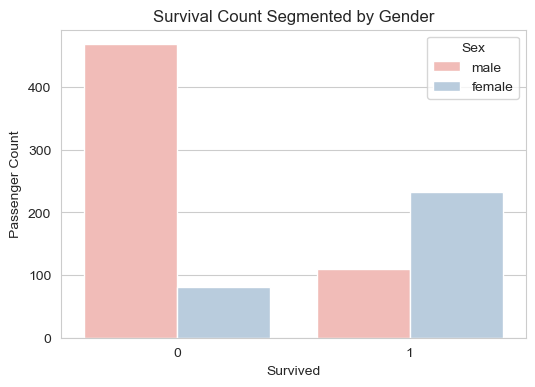

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', hue='Sex', data=df, palette='Pastel1')
plt.title('Survival Count Segmented by Gender')
plt.ylabel('Passenger Count')
plt.show()

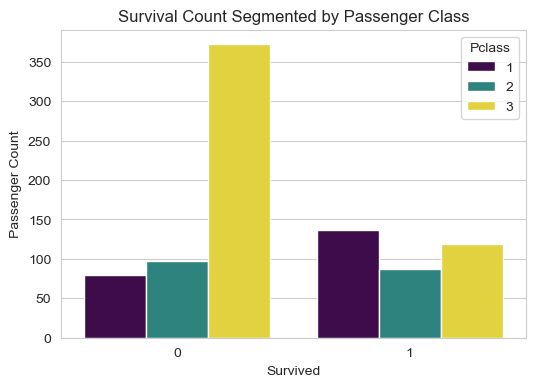

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', hue='Pclass', data=df, palette='viridis')
plt.title('Survival Count Segmented by Passenger Class')
plt.ylabel('Passenger Count')
plt.show()

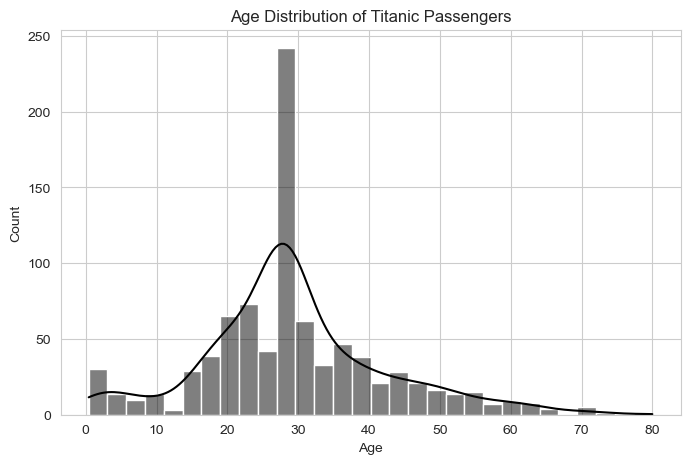

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True, color='black')
plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()